In [1]:
import sys
sys.path.append(r"E:\code\CubiCasa5k")  # 确认是实际项目路径

Running MATLAB script in the background...
MATLAB calculation completed.


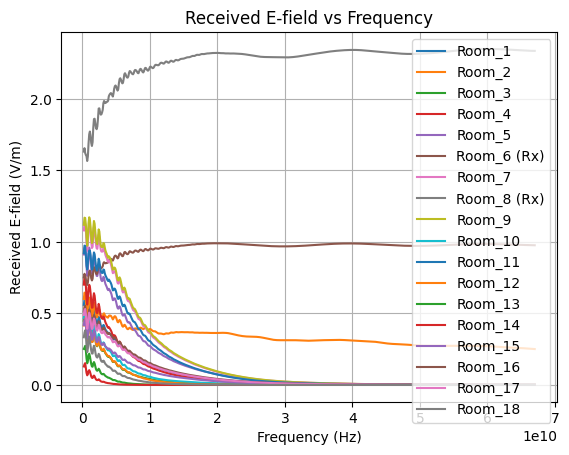

Output()

In [5]:
# indoor_emt_analysis.py
# Functions: MATLAB integration, power-frequency curves, optimized interactive heatmap
# Dependencies: matlab.engine, numpy, matplotlib, pillow, ipywidgets, scipy

import numpy as np
import matlab.engine
from matplotlib import pyplot as plt
from PIL import Image
from ipywidgets import interact, SelectionSlider, FloatText, HBox, VBox, interactive_output
from indoor_topology.extract_rooms import extract_rooms
from scipy.ndimage import center_of_mass
from IPython.display import display  # 添加缺失的display导入


# Fetch results from MATLAB including source powers
def fetch_matlab_results(script_path):
    print("Running MATLAB script in the background...")
    eng = matlab.engine.start_matlab()
    eng.eval(f"run('{script_path}')", nargout=0)
    resultMatrix = np.array(eng.workspace['resultMatrix'])
    freq_vector = np.array(eng.workspace['frequency']).flatten()
    S_in_dBm = np.array(eng.workspace['S_in_dBm']).flatten()
    eng.quit()
    print("MATLAB calculation completed.")

    room_ids = resultMatrix[:, 0].astype(int)
    E_matrix = resultMatrix[:, 1:]

    # Identify source rooms and their powers
    source_rooms = room_ids[S_in_dBm > -np.inf]
    source_powers = {room_id: power for room_id, power in zip(room_ids, S_in_dBm) if power > -np.inf}

    return room_ids, E_matrix, freq_vector, source_rooms, source_powers


# Plot E-frequency curves with Rx source indication
def plot_E_curves(room_ids, E_matrix, freq_vector, source_rooms):
    plt.figure()
    for i, room_id in enumerate(room_ids):
        label = f"Room_{room_id}"
        if room_id in source_rooms:
            label += " (Rx)"
        plt.plot(freq_vector, E_matrix[i, :], label=label)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Received E-field (V/m)")
    plt.title("Received E-field vs Frequency")
    plt.legend()
    plt.grid()
    plt.show()


# Optimized interactive heatmap function
def interactive_heatmap(region_id_map, room_ids, E_matrix, freq_vector, base_image_path, source_rooms, source_powers):
    base_img = Image.open(base_image_path).convert("RGBA")
    cmap = plt.cm.jet
    E_min, E_max = E_matrix.min(), E_matrix.max()

    freq_labels = [f"{freq / 1e9:.2f} GHz" for freq in freq_vector]
    freq_options = {label: idx for idx, label in enumerate(freq_labels)}

    # Compute centers for room IDs display
    room_centers = {room_id: center_of_mass(region_id_map == room_id) for room_id in room_ids}

    heatmap_images = []
    for freq_idx in range(len(freq_vector)):
        overlay = np.zeros(region_id_map.shape + (4,), dtype=np.uint8)
        for i, room_id in enumerate(room_ids):
            norm_E = (E_matrix[i, freq_idx] - E_min) / (E_max - E_min)
            color = cmap(norm_E, alpha=0.6)
            overlay[region_id_map == room_id] = (np.array(color[:4]) * 255).astype(np.uint8)

        overlay_img = Image.fromarray(overlay, mode='RGBA')
        composite_img = Image.alpha_composite(base_img, overlay_img)
        heatmap_images.append(composite_img)

    slider = SelectionSlider(
        options=freq_labels,
        description='Frequency Slider',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout={'width': '70%'}
    )

    freq_input = FloatText(
        value=float(freq_labels[0][:-4]),
        description='Frequency Input (GHz)',
        step=0.1,
        style={'description_width': 'initial'},
        layout={'width': '30%'}
    )

    def sync_input_to_slider(change):
        freq_value = f"{change.new:.2f} GHz"
        if freq_value in freq_options:
            slider.value = freq_value

    def sync_slider_to_input(change):
        freq_input.value = float(change.new[:-4])

    freq_input.observe(sync_input_to_slider, names='value')
    slider.observe(sync_slider_to_input, names='value')

    def update(freq_label):
        freq_idx = freq_options[freq_label]
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(heatmap_images[freq_idx])
        ax.set_title(f"Heatmap at Frequency {freq_label}")
        ax.axis("off")

        for i, room_id in enumerate(room_ids):
            y, x = room_centers[room_id]
            ax.text(x, y, f"Room_{room_id}\n{E_matrix[i, freq_idx]:.2f}", color='white', fontsize=8,
                    ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

            if room_id in source_rooms:
                circle = plt.Circle((x, y), radius=15, color='yellow', fill=True, alpha=0.9)
                ax.add_patch(circle)
                power_label = f"{source_powers[room_id]} dBm"
                ax.text(x, y - 25, power_label, color='yellow', fontsize=9,
                        ha='center', va='center', bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=E_min, vmax=E_max))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label="Received E-field (V/m)").ax.set_aspect('auto')
        plt.show()

    controls = VBox([HBox([slider, freq_input])])
    out = interactive_output(update, {'freq_label': slider})
    display(controls, out)

    # Main execution block
if __name__ == "__main__":
    matlab_script = r"E:\code\IndoorEMT\debug_roomself_wall.m"

    wall_svg_path = "wall_svg.png"
    rough_img_path = "svgImg_roughcast.png"

    wall_label_img = Image.open(wall_svg_path).convert('P')
    wall_label_array = np.array(wall_label_img)

    # Fetch MATLAB results, including source rooms and powers
    room_ids, E_matrix, freq_vector, source_rooms, source_powers = fetch_matlab_results(matlab_script)

    plot_E_curves(room_ids, E_matrix, freq_vector, source_rooms)

    region_id_map, rooms, _, _ = extract_rooms(wall_label_array)

    interactive_heatmap(region_id_map, room_ids, E_matrix, freq_vector, rough_img_path, source_rooms, source_powers)

# jupyter notebook
# import sys
# sys.path.append(r"E:\code\CubiCasa5k")  # Confirm the actual project path
